# `hw3`: Bayesian inference of Oxygen Saturation from Photoplethysmography


Deadline: **Friday, December 13, 11:59 PM**. 
- Submit your completed notebook on your personal Github repository created when accepting the assignment.
- All cells must be executable and their outputs should not be erased before submission.
- Homeworks are carried out *individually*.

In [1]:
# Fill in this cell with your personal details:
# - Name: Alexandre Dutailly
# - Student ID: S195855
# - Email: alexandre.dutaily@student.uliege.be

In this homework, you will have to infer oxygen saturation (SPO2 / SO2) measures from unprocessed photoplethysmography (PPG) using data from the [OpenOximetry Repository](https://physionet.org/content/openox-repo/1.0.1). More precisely, you will build a small probabilistic model of PPG from SpO2, and infer some physical parameters along with the unknown SpO2 from the observed PPG data. See homework 1 for instructions on how to handle the dataset, and homework 2 for instruction on how to prepare the data for inference.

## Oximeter

An [oximeter](https://en.wikipedia.org/wiki/Pulse_oximetry) is a medical device that estimates the **blood oximetry**, or **oxygen saturation** ($\text{SpO2}$), using the two [photoplethysmographs](https://en.wikipedia.org/wiki/Photoplethysmogram) obtained by illuminating the skin at two different wavelengths (red at $\lambda = 660 \text{nm}$ and infrared at $\lambda = 940 \text{nm}$).
Note that the oxygen saturation ($\text{SpO2}$), is defined as the ratio of the concentration of oxygenated hemoglobyn by the total concentration of hemoglobyn,
$$
    \text{SpO2} = \frac{[Hb02]}{[Hb02] + [Hb]}.
$$
The estimation made by the oximeter is based on the difference of light absorption bewteen the oxygenated hemoglobin (HbO2) and deoxygenated hemoglobin (Hb) at two different wavelengths (see details below in the probabilistic model). 

Because many factors alter the absorbance of the light by the skin, it usually assumed that only the **pulsative component** $\text{AC}$ of a cardiac cycle is due to the variation of the blood pressure. The **pulsative component** $\text{AC}(\lambda)$ at a given wavelength $\lambda$ during a cycle that spans from $t=t_1$ to $t=t_2$ is defined as, 
$$
    \text{AC}(\lambda) = \max(\text{PPG}(\lambda)_{t_1:t_2}) - \min(\text{PPG}(\lambda)_{t_1:t_2}),
$$
while the **non pulsative component** $\text{DC}(\lambda)$ at a given wavelength $\lambda$ is defined as,
$$
    \text{DC}(\lambda) = \text{mean}(\text{PPG}(\lambda)_{t_1:t_2}). 
$$
Since the **non pulsative component** is assumed to be mainly caused by other factors (skin color, skin tissues, veins, etc), oximeters usually focus on the **pulsative component**. Accordingly, they consider their observation to be the **ratio** ($R$) of the **pulsative components**, normalized by the **nonpulsative components**, at the two different wavelengths,
$$
    R
    =
    \frac{
        \text{AC}(660 \text{nm})/\text{DC}(660 \text{nm})
    }{
        \text{AC}(940 \text{nm})/\text{DC}(940 \text{nm})
    }.
$$


## Probabilistic Model

In this homework, we assume the following probabilistic model from the oxygen saturation ($\text{SpO2}$) and 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660 \text{nm})$, $\epsilon_\text{Hb}(660 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$) to the observed ratio ($R$).

The Beer-Lambert law state that the absorption of light of a substance in a solution is proportional to its concentration, such that the absorption of the blood at a given wavelength $\lambda$ can be written,
$$
    A(\lambda) = \text{SpO2} \; \epsilon_\text{Hb02}(\lambda) + (1 - \text{SpO2}) \; \epsilon_\text{Hb}(\lambda).
$$

Assuming that the ratio ($R$) of normalized pulsative signals is proportional to the ratio of aborbances at the two wavelengths, we propose the following model, 
$$
    R
    \sim
    \mathcal{N}\left(
        \frac{
            \text{SpO2} \; \epsilon_\text{Hb02}(660 \text{nm}) + (1 - \text{SpO2}) \; \epsilon_\text{Hb}(660 \text{nm})
        }{
            \text{SpO2} \; \epsilon_\text{Hb02}(940 \text{nm}) + (1 - \text{SpO2}) \; \epsilon_\text{Hb}(940 \text{nm})
        },
        \sigma^2
    \right).
$$

The input ($\text{SpO2}$) and the 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660 \text{nm})$, $\epsilon_\text{Hb}(660 \text{nm})$ are unknown. We nevertheless report below some empirical absorption coefficients should help finding good informative priors for these coefficients: [https://omlc.org/spectra/hemoglobin/summary.html](https://omlc.org/spectra/hemoglobin/summary.html).

<div class="alert alert-info">
    
**Information**. We provide the functions `extract_beats` and some empirical absorption coefficients.
    
</div>

In [2]:
import os
import emcee
import corner
import warnings
import wfdb as wf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import norm, gamma
from scipy.signal import butter, filtfilt, resample, find_peaks

warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
EPS_HBO2_660 = 319.6
EPS_HB_660 = 3226.56

EPS_HBO2_940 = 1214
EPS_HB_940 = 693.44

In [4]:
def extract_beats(ppg, f_ppg, min_time_between=0.4):
    """
    Arguments:
    ----------
    ppg: np.ndarray
        A one dimensional time series of ppg data (red or ir).
    f_ppg: int
        The sampling frequency (Hz).
    min_time_between: float
        The minimal time between two heartbeats.

    Returns:
    --------
    - peaks: np.ndarray
        The indices of the heartbeats peaks in the ppg time series.
    """
    min_number_between = int(min_time_between * f_ppg)
    peaks, _ = find_peaks(ppg, distance=min_number_between)
    return peaks

# Exercises

- Solve the exercises below by making the best use of the API offered in the imported libraries.
- You will also need to use the `wfdb` library for reading and writing waveform data (see [WFDB Documentation](https://wfdb.readthedocs.io/en/latest/wfdb.html)).
- For plots, feel free to use `matplotlib`, `seaborn` or `pandas` built-in plotting functions.
- Follow the data visualization principles as best as possible to make your plots effective and readable.
- For each exercise, add Markdown cells to explain what you are doing and to discuss your results.

<div class="alert alert-info">
    
**Information**. In this homework, we focus on encounter `c5dd95c1ac9fc618cab2e940096089c6a91be58206fa6fc6a1375c69c4922779`. Below, we load the SpO2 data from `f'{encounter_id}_2hz.csv'` (device 59) and the PPG data from `f'{encounter_id}_ppg.dat'`. 
    
</div>

<div class="alert alert-danger">

**Warning**. Note that the PPG recording starts approximately 2.80 min after the SpO2, and it is shifted accordingly.

</div>

In [5]:
encounter_id = "c5dd95c1ac9fc618cab2e940096089c6a91be58206fa6fc6a1375c69c4922779"

In [6]:
f_spo2 = 2

start = 5 * 60

saturation = pd.read_csv(f'data/waveforms/{encounter_id[0]}/{encounter_id}_2hz.csv')
spo2 = saturation['dev59_SpO2'].to_numpy()[start * f_spo2:]
t_spo2 = np.arange(spo2.shape[0]) / (60 * f_spo2)

In [7]:
f_ppg = 86

start = (5 - 2.8) * 60

ppg, ppg_info = wf.rdsamp(f'data/waveforms/{encounter_id[0]}/{encounter_id}_ppg')
ppg = ppg[int(start * f_ppg):]

ir = ppg[:, 0]
red = ppg[:, 1]
t_ppg = np.arange(len(red)) / (60 * f_ppg)

## Part 1: Data Preparation

<div class="alert alert-info">

**Information**. In this part, you should simply reproduce the data preparation steps from Homework 2.

</div>

<div class="alert alert-success">
    
**Exercise** (identical to Homework 2). Using the function `extract_beats`, find all starts of cardiac cycles (the peak of the heart beat) $t_1, t_2, \dots, t_N$ using one of the two PPG signals (red or infrared).
    
For both PPG signals, compute the pulsative component ($\text{AC}(\lambda)$) and non pulsative component ($\text{DC}(\lambda)$) for each heart cycle. Then, compute the ratio $R$ of normalized pulsative components. 

You now have $N$ ratios (one for each cardiac cycle), and $M$ saturation measurements (one every 0.5 second). Resample the ratio $R$ at the same times as the $\text{SpO2}$ time series so that the two time series are paired.

For simplicity, subsample only one every 200 ratios ($R$) and one every 200 oxygen saturation ($\text{SpO2}$).

</div>

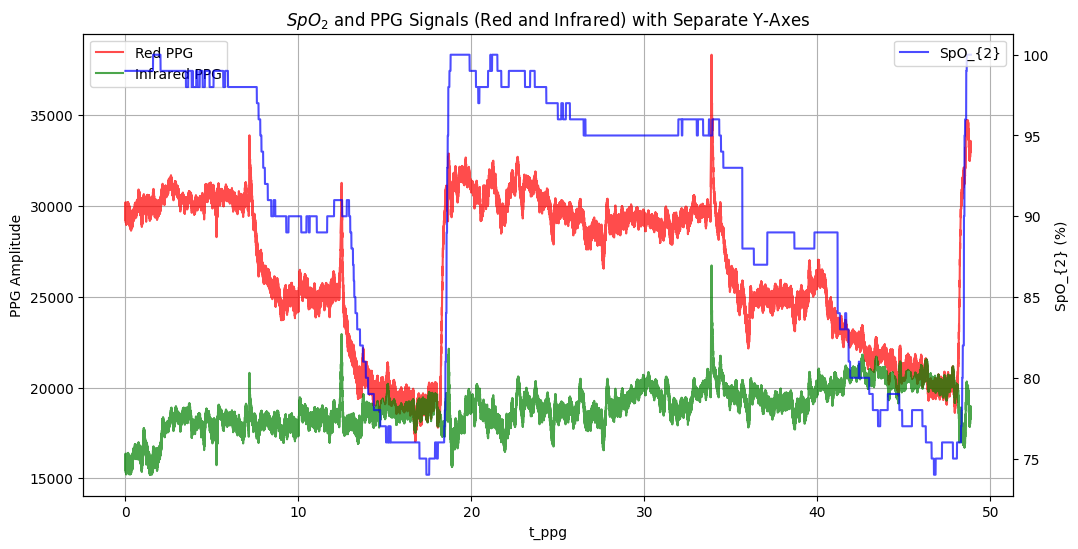

Nombre de battements détectés red: 4291
Nombre de battements détectés ir: 4317


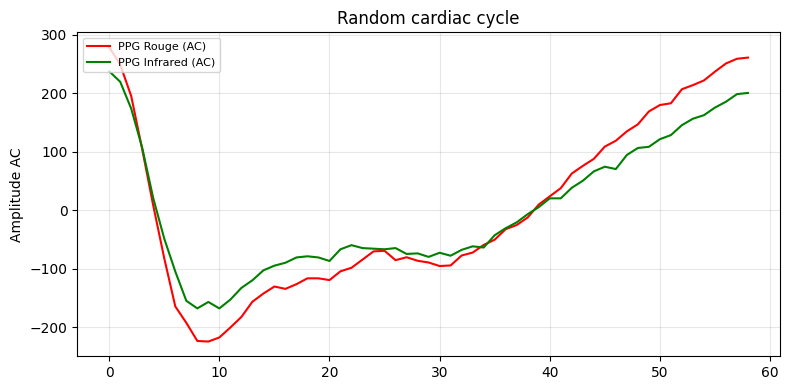

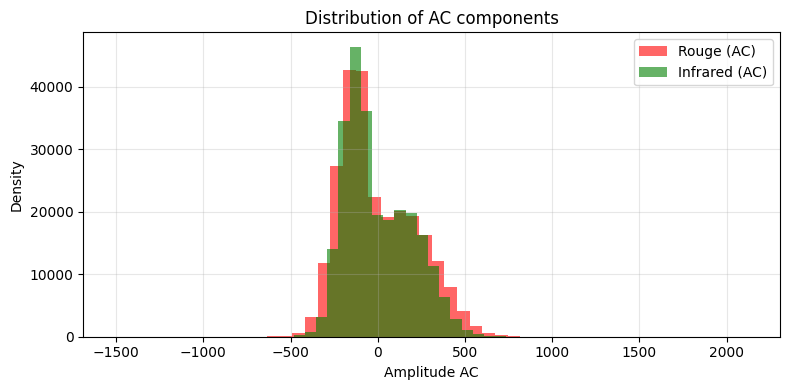

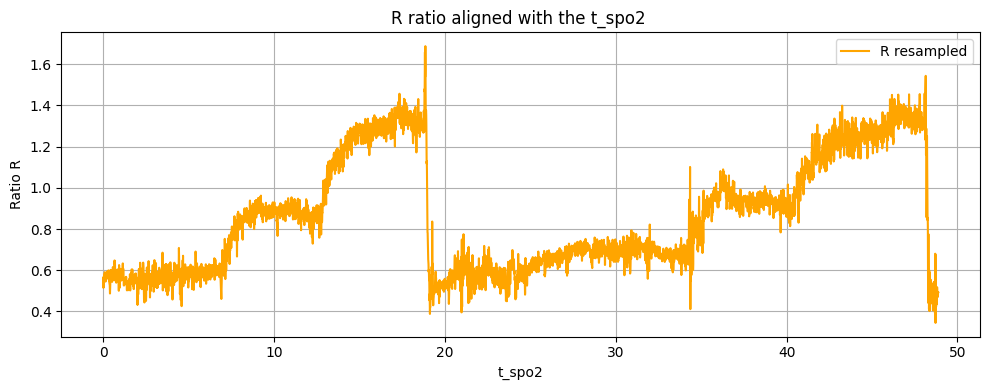

SpO_2 size after sub-sampling : 30
R size after sub-sampling : 30


In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(t_ppg, red, label="Red PPG", color='red', alpha=0.7)
ax1.plot(t_ppg, ir, label="Infrared PPG", color='green', alpha=0.7)
ax1.set_xlabel("t_ppg")
ax1.set_ylabel("PPG Amplitude")
ax1.legend(loc="upper left")
ax1.grid(True)

# Create a secondary y-axis for SpO
ax2 = ax1.twinx()
ax2.plot(t_spo2, spo2, label="SpO_{2}", color='blue', alpha=0.7)
ax2.set_ylabel("SpO_{2} (%)")
ax2.legend(loc="upper right")


plt.title("$SpO_{2}$ and PPG Signals (Red and Infrared) with Separate Y-Axes")
plt.show()

beats = extract_beats(red, f_ppg=f_ppg, min_time_between=0.4)
beats1 = extract_beats(ir, f_ppg=f_ppg, min_time_between=0.4)
print(f"Nombre de battements détectés red: {len(beats)}")
print(f"Nombre de battements détectés ir: {len(beats1)}")

ac_red, dc_red, ac_ir, dc_ir = [], [], [], []
ac_r, ac_i = [], []
seg_i, seg_r = [], []
seg_r.append(red[:beats[0]])
seg_i.append(ir [:beats[0]])


for i in range(len(beats) - 1):
    a, b = beats[i], beats[i + 1]
    seg_r.append(red[a:b])
    seg_i.append(ir [a:b])

for r_seg, i_seg in zip(seg_r, seg_i):
    ac_red.append(r_seg.max() - r_seg.min())
    dc_red.append(r_seg.mean())
    ac_ir.append(i_seg.max() - i_seg.min())
    dc_ir.append(i_seg.mean())

    ac_r.append(r_seg - r_seg.mean())
    ac_i.append(i_seg - i_seg.mean())



k = np.random.randint(0, len(ac_r))
a, b = beats[k], beats[k+1]
t_cycle = np.arange(a, b) / f_ppg

plt.figure(figsize=(8,4))
plt.plot(ac_r[k], label="PPG Rouge (AC)",color='red')
plt.plot(ac_i[k], label="PPG Infrared (AC)", color='green')
plt.xlabel("")
plt.ylabel("Amplitude AC")
plt.title("Random cardiac cycle")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


all_red_ac = np.hstack(ac_r)
all_ir_ac = np.hstack(ac_i)

plt.figure(figsize=(8,4))
plt.hist(all_red_ac, bins=50, alpha=0.6, label="Rouge (AC)", color='red')
plt.hist(all_ir_ac, bins=50, alpha=0.6, label="Infrared (AC)", color='green')
plt.xlabel("Amplitude AC")
plt.ylabel("Density")
plt.title("Distribution of AC components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

R = (np.array(ac_red)/np.array(dc_red)) / (np.array(ac_ir)/np.array(dc_ir))
R_resampled = resample(R, len(spo2)) 
t_spo2 = np.arange(len(spo2)) * (0.5/60) 

plt.figure(figsize=(10,4))
plt.plot(t_spo2, R_resampled, color='orange', label='R resampled')
plt.xlabel("t_spo2")
plt.ylabel("Ratio R")
plt.title("R ratio aligned with the t_spo2 ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

subsampling_factor = 200
spo2_subsampled = spo2[::subsampling_factor]
R_subsampled = R_resampled[::subsampling_factor]


print(f"SpO_{2} size after sub-sampling : {len(spo2_subsampled)}")
print(f"R size after sub-sampling : {len(R_subsampled)}")

<div class="alert alert-success">
    
**Exercise** (identical to Homework 2). Write a `sample_likelihood` function that takes as arguments an array $\text{SpO2}_{1:T}$ of $T$ oxygen saturation measurements (caution, it is expressed in %), along with the 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660nm)$, $\epsilon_\text{Hb}(660nm)$, $\epsilon_\text{HbO2}(940nm)$, $\epsilon_\text{HbO2}(940nm)$), and that returns $n$ realisation of the ratio $R$ for each of the $T$ inputs. You are free to choose any alternate parametrization for the parameters.

Write a `log_likelihood` function that takes the same arguments as `sample_likelihood`, along with a ratio ($R$), and returns the log likelihood of this ratio according to the probabilistic model.

</div>

In [9]:
def sample_likelihood(spo2_array, params, n_samples):

    sigma = params["sigma"]
    epsilon_HbO2_660 = params["epsilon_HbO2_660"]
    epsilon_Hb_660 = params["epsilon_Hb_660"]
    epsilon_HbO2_940 = params["epsilon_HbO2_940"]
    epsilon_Hb_940 = params["epsilon_Hb_940"]
    
    spo2_array = spo2_array/ 100
    A_660 = (spo2_array * epsilon_HbO2_660 + (1 - spo2_array) * epsilon_Hb_660)
    A_940 = (spo2_array * epsilon_HbO2_940 + (1 - spo2_array) * epsilon_Hb_940)
    R_mean = (A_660) /A_940
    
    samples = np.random.normal(R_mean,sigma,(len(spo2_array), n_samples))
    
    return samples


In [10]:
def log_likelihood(spo2_array, params, R_observed):
    sigma = params["sigma"]
    epsilon_HbO2_660 = params["epsilon_HbO2_660"]
    epsilon_Hb_660 = params["epsilon_Hb_660"]
    epsilon_HbO2_940 = params["epsilon_HbO2_940"]
    epsilon_Hb_940 = params["epsilon_Hb_940"]

    spo2_array = spo2_array/ 100
    A_660 = (spo2_array * epsilon_HbO2_660 + (1 - spo2_array) * epsilon_Hb_660)
    A_940 = (spo2_array * epsilon_HbO2_940 + (1 - spo2_array) * epsilon_Hb_940)
    R_mean = (A_660) /A_940
    
    return - norm.logpdf(R_observed, R_mean, sigma).sum()


## Part 2: Inference

<div class="alert alert-info">

**Information**. We will now consider a fully Bayesian model where both the input ($\text{SpO2}$) and the 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660 \text{nm})$, $\epsilon_\text{Hb}(660 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$) also become random variables with their own priors.

</div>

<div class="alert alert-success">
    
**Exercise**. Write the mathematical expression of the joint density,
$$
    p(R, \text{SpO2}, \sigma^2, \epsilon_\text{HbO2}(660 \text{nm}), \epsilon_\text{Hb}(660 \text{nm}), \epsilon_\text{HbO2}(940 \text{nm}), \epsilon_\text{HbO2}(940 \text{nm})).
$$
    
</div>

**Note.** In the statement, the term $\epsilon_{\mathrm{HbO_2}}(940\text{nm})$ appears twice. For the rest of the text, we interpret the **second** term (the one on the right) as a typo and replace it with $\epsilon_{\mathrm{Hb}}(940\text{nm})$.

We will consider the following expression of the joint density,

$$
p\!\big(
R,\ \mathrm{SpO}_2,\ \sigma^2,\ 
\varepsilon_{\mathrm{HbO_2}}(660\text{nm}),\ 
\varepsilon_{\mathrm{Hb}}(660\text{nm}),\ 
\varepsilon_{\mathrm{HbO_2}}(940\text{nm}),\ 
\varepsilon_{\mathrm{Hb}}(940\text{nm})
\big).
$$
We start from the target joint distribution above.  
The likelihood term is

$$
p\!\left(R \mid \mathrm{SpO}_2,\ \sigma^2,\ \varepsilon_{\mathrm{HbO_2}}(660\text{nm}),\ \varepsilon_{\mathrm{Hb}}(660\text{nm}),\ \varepsilon_{\mathrm{HbO_2}}(940\text{nm}),\ \varepsilon_{\mathrm{Hb}}(940\text{nm})\right)
$$

Assuming mutual independence among all parameters, the prior factorizes as

$$
\begin{aligned}
&p\!\left(\mathrm{SpO}_2,\ \sigma^2,\ \varepsilon_{\mathrm{HbO_2}}(660\text{nm}),\ \varepsilon_{\mathrm{Hb}}(660\text{nm}),\ \varepsilon_{\mathrm{HbO_2}}(940\text{nm}),\ \varepsilon_{\mathrm{Hb}}(940\text{nm})\right) \\
&= p(\mathrm{SpO}_2)\; p(\sigma^2)\; p\!\left(\varepsilon_{\mathrm{HbO_2}}(660\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{Hb}}(660\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{HbO_2}}(940\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{Hb}}(940\text{nm})\right)

\end{aligned}
$$

Therefore, the joint density can be written as


\begin{aligned}
&p\!\big(R,\ \mathrm{SpO}_2,\ \sigma^2,\ \varepsilon_{\mathrm{HbO_2}}(660\text{nm}),\ \varepsilon_{\mathrm{Hb}}(660\text{nm}),\ \varepsilon_{\mathrm{HbO_2}}(940\text{nm}),\ \varepsilon_{\mathrm{Hb}}(940\text{nm})\big) \\
&= p\!\left(R \mid \mathrm{SpO}_2,\ \sigma^2,\ \varepsilon_{\mathrm{HbO_2}}(660\text{nm}),\ \varepsilon_{\mathrm{Hb}}(660\text{nm}),\ \varepsilon_{\mathrm{HbO_2}}(940\text{nm}),\ \varepsilon_{\mathrm{Hb}}(940\text{nm})\right) \\
&\quad \times\ p(\mathrm{SpO}_2)\; p(\sigma^2)\; p\!\left(\varepsilon_{\mathrm{HbO_2}}(660\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{Hb}}(660\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{HbO_2}}(940\text{nm})\right)\; p\!\left(\varepsilon_{\mathrm{Hb}}(940\text{nm})\right)\\
\end{aligned}



<div class="alert alert-success">
    
**Exercise**. Select and discuss some prior distribution for both the input ($\text{SpO2}$) and the 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660 \text{nm})$, $\epsilon_\text{Hb}(660 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$, $\epsilon_\text{HbO2}(940 \text{nm})$).  Write a `sample_prior` function that returns samples from this prior distribution. Write a `log_prior` that returns the log probability of inputs and parameters. Finally, write a `sample_joint` function that returns samples from the joint distribution over input, parameters and ratios.
    
</div>

In [ ]:

def sample_prior(n_samples, spo2_val):

    samples = {
     
        "sigma": np.random.gamma(0.4, scale=0.02, size=n_samples),  
        
        "epsilon_HbO2_660": np.random.normal(EPS_HBO2_660, scale=50, size=n_samples), 
        "epsilon_Hb_660": np.random.normal(EPS_HB_660, scale=50, size=n_samples),
        "epsilon_HbO2_940": np.random.normal(EPS_HBO2_940, scale=50, size=n_samples),
        "epsilon_Hb_940": np.random.normal(EPS_HB_940, scale=50, size=n_samples),
    
        "SpO2": np.random.normal(spo2_val,scale= 0.01,size=(n_samples, len(spo2_val)))

    }
    return samples


In [ ]:
def log_prior(params, spo2_val):
    sigma = params["sigma"]
    epsilon_HbO2_660 = params["epsilon_HbO2_660"]
    epsilon_Hb_660 = params["epsilon_Hb_660"]
    epsilon_HbO2_940 = params["epsilon_HbO2_940"]
    epsilon_Hb_940 = params["epsilon_Hb_940"]
    spo2_eval = params["SpO2"] 

    if (np.any((spo2_eval < 0) | (spo2_eval > 100) | np.isnan(spo2_eval))):
        return -np.inf
    
    log_prior_sigma2 = gamma.logpdf(sigma,a=1, loc=0.0, scale=0.001)

    log_prior_spo2 = np.sum(norm.logpdf(spo2_eval, loc=spo2_val, scale=0.1))
    log_prior_eps_660 = norm.logpdf(epsilon_HbO2_660, loc=EPS_HBO2_660, scale=5)
    log_prior_eps_660_hb = norm.logpdf(epsilon_Hb_660, loc=EPS_HB_660, scale=50)
    log_prior_eps_940 = norm.logpdf(epsilon_HbO2_940, loc=EPS_HBO2_940, scale=25)
    log_prior_eps_940_hb = norm.logpdf(epsilon_Hb_940, loc=EPS_HB_940, scale=5)

    return (
        log_prior_sigma2 +
        log_prior_eps_660 +
        log_prior_eps_660_hb +
        log_prior_eps_940 +
        log_prior_eps_940_hb +
        log_prior_spo2
    )

In [13]:
def sample_joint(n_samples, spo2_val):

    prior_samples = sample_prior(n_samples, spo2_val)
    
    ratios = (
        (prior_samples["SpO2"]/100 * prior_samples["epsilon_HbO2_660"][:, None] +
         (1 - prior_samples["SpO2"]/100) * prior_samples["epsilon_Hb_660"][:, None]) /
        (prior_samples["SpO2"]/100 * prior_samples["epsilon_HbO2_940"][:, None] +
         (1 - prior_samples["SpO2"]/100) * prior_samples["epsilon_Hb_940"][:, None])
    )
    sigma = prior_samples["sigma"][:, None]
    R_samples = np.random.normal(ratios, sigma, size=ratios.shape)
    prior_samples["Ratios"] = R_samples
    return prior_samples


<div class="alert alert-success">
    
**Exercise**. Adjust and discuss your final choice of priors $p(\text{SpO2})$, $p(\sigma^2)$, $p(\epsilon_\text{HbO2}(660 \text{nm}))$, $p(\epsilon_\text{Hb}(660 \text{nm}))$, $p(\epsilon_\text{HbO2}(940 \text{nm}))$, $p(\epsilon_\text{HbO2}(940 \text{nm}))$ through prior predictive checks of $R$.
    
</div>

In [14]:

def sample_prior(n_samples, spo2_val):

    samples = {
     
        "sigma": np.random.gamma(0.4, scale=0.02, size=n_samples),  
        
        "epsilon_HbO2_660": np.random.normal(EPS_HBO2_660*1.6, scale=EPS_HBO2_660*0.15, size=n_samples), 
        "epsilon_Hb_660": np.random.normal(EPS_HB_660*1.15, scale=EPS_HB_660*0.15, size=n_samples),
        "epsilon_HbO2_940": np.random.normal(EPS_HBO2_940*0.95, scale=EPS_HBO2_940*0.15, size=n_samples),
        "epsilon_Hb_940": np.random.normal(EPS_HB_940*0.9, scale=EPS_HB_940*0.15, size=n_samples),
    
        "SpO2": np.clip(np.random.normal(spo2_val,scale= spo2_val*0.01,size=(n_samples, len(spo2_val))),0, 100)

    }
    return samples


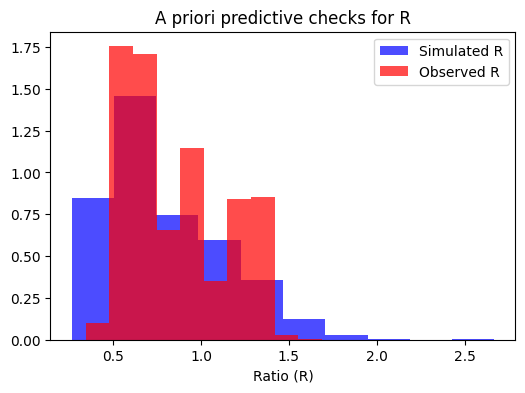

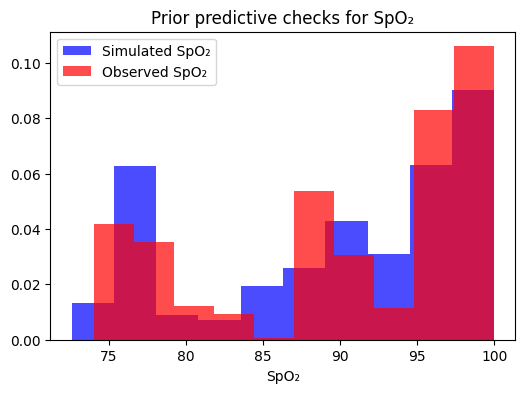

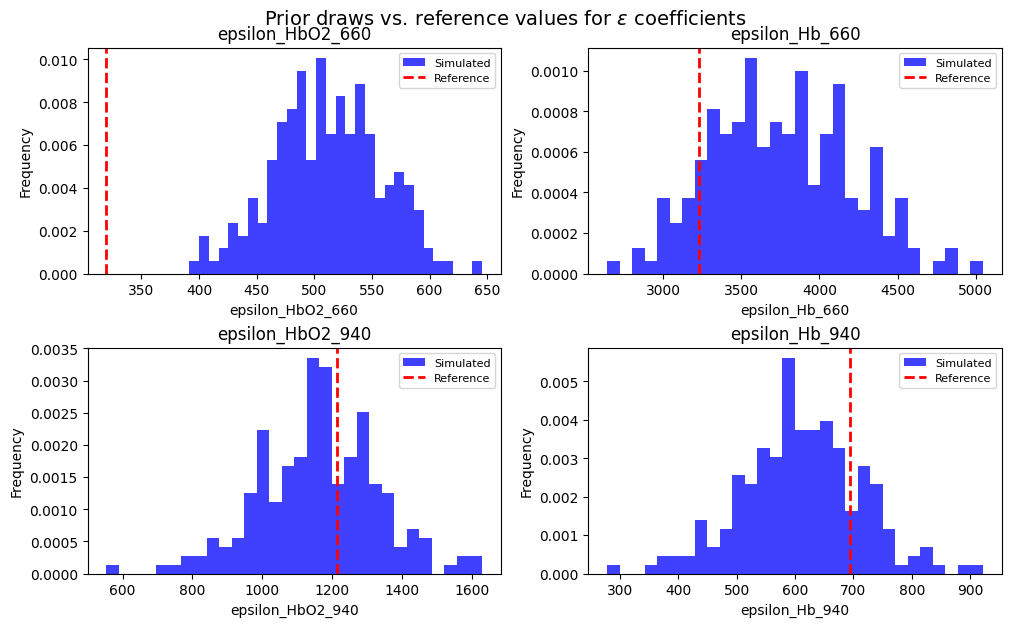

In [22]:
n_samples = 200
prior_samples = sample_joint(n_samples, spo2_subsampled)

plt.figure(figsize=(6,4))
plt.hist(prior_samples["Ratios"].flatten(),density=True, bins=10,
         alpha=0.7, color="blue", label="Simulated R")

plt.hist(R_resampled, density=True,bins=10,
          alpha=0.7, color="red", label="Observed R")

plt.xlabel("Ratio (R)")
plt.title("A priori predictive checks for R")
plt.legend()
plt.show()


plt.figure(figsize=(6,4))
plt.hist(prior_samples["SpO2"].flatten(), density=True,bins=10, alpha=0.7, color="blue",  label="Simulated SpO₂")
plt.hist(spo2,density=True, bins=10, alpha=0.7, color="red",label="Observed SpO₂")

plt.xlabel("SpO₂")
plt.title("Prior predictive checks for SpO₂")
plt.legend()
plt.show()

params = ["epsilon_HbO2_660",
          "epsilon_Hb_660",
          "epsilon_HbO2_940",
          "epsilon_Hb_940"]

reference = {
    "epsilon_HbO2_660": EPS_HBO2_660,
    "epsilon_Hb_660"  : EPS_HB_660,
    "epsilon_HbO2_940": EPS_HBO2_940,
    "epsilon_Hb_940"  : EPS_HB_940
}

params = list(reference.keys())
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes = axes.flatten()

for ax, p in zip(axes, params):

    ax.hist(prior_samples[p].ravel(),density=True, bins=30, alpha=0.75, color="blue", label="Simulated")
    ax.axvline(reference[p], color="red", linestyle="--", linewidth=2, label="Reference")

    ax.set_title(p)
    ax.set_xlabel(p)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Prior draws vs. reference values for $\\epsilon$ coefficients", y=1.02, fontsize=14)
plt.show()





After several modifications to try errors in order to arrive at a better distribution for the approximation of $SpO_2$ and the ratio we arrive at the `sample_prior` above.

For $SpO_2$ I had to make a very small scale in order to have a distribution which remains within the observed values and thus relatively resembles the distribution of the observed values. I then applied a clip which restrains the $SpO_2$ values so that they don't exceed the 0% and 100% limits, as this is not possible.

For the ratio, I had to modify the basic $\epsilon$ given in the statement. This concentrates the values of the ratio on those calculated on the basis of the $SpO_2$ and $\epsilon$ in the statement. However, we find that the distribution of simulated values exceeds the observed values.


<div class="alert alert-success">
    
**Exercise**. Write a `log_posterior` function that returns the logarithm of the (unormalized) posterior probability density function,
$$
    p(\text{SpO2}_{1:T}, \sigma^2, \epsilon_\text{HbO2}(660 \text{nm}), \epsilon_\text{Hb}(660 \text{nm}), \epsilon_\text{HbO2}(940 \text{nm}), \epsilon_\text{HbO2}(940 \text{nm}) \mid R_{1:T}),
$$
using your previously defined priors.
    
</div>

In [ ]:
def log_posterior(theta, R_obs, spo2_val):

    sigma = theta[0]
    eps_HbO2_660 = theta[1]
    eps_Hb_660 = theta[2]
    eps_HbO2_940 = theta[3]
    eps_Hb_940 = theta[4]
    SpO2 = theta[5:]

    params = {
        "sigma" : sigma,
        "epsilon_HbO2_660" : eps_HbO2_660,
        "epsilon_Hb_660" : eps_Hb_660,
        "epsilon_HbO2_940" : eps_HbO2_940,
        "epsilon_Hb_940" : eps_Hb_940,
        "SpO2" : SpO2
    }
    

    lp = log_prior(params, spo2_val)
    if not np.isfinite(lp):
        return -np.inf
    

    ll = log_likelihood(SpO2, params, R_obs)
    if not np.isfinite(ll):
        return -np.inf


    return lp - ll


I used the log-likelihood we made during this homework, but I applied some checks to ensure that the MCMC converged without any problems or incorrect values.

<div class="alert alert-success">
    
**Exercise**. Use MCMC to compute the posterior distribution given the observed ratios $R_{1:T}$. The posterior distribution is computed on $5$ parameters and $T$ $\text{SpO2}$ values, where $T$ is the number of ratios you subsampled in the time series of ratios.

</div>

In [17]:
n_params = 5 

T = spo2_subsampled.size
n_dim = n_params + T 
n_walkers =4* n_dim
print(f"Nombre de marcheurs : {n_walkers}")
n_steps = 100000

prior = sample_prior(n_walkers, spo2_subsampled)


initial_positions = np.zeros((n_walkers, n_dim))

initial_positions[:, 0] = prior["sigma"]
initial_positions[:, 1] = prior["epsilon_HbO2_660"]
initial_positions[:, 2] = prior["epsilon_Hb_660"]
initial_positions[:, 3] = prior["epsilon_HbO2_940"]
initial_positions[:, 4] = prior["epsilon_Hb_940"]
initial_positions[:, 5:5+T] = prior["SpO2"]



sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(R_subsampled, spo2_subsampled))

print("Exécution de l'échantillonnage MCMC...")
sampler.run_mcmc(initial_positions, n_steps, progress=True)




Nombre de marcheurs : 140
Exécution de l'échantillonnage MCMC...


100%|██████████| 100000/100000 [1:27:22<00:00, 19.08it/s]    


State([[1.16454756e-01 3.31762148e+02 3.35590936e+03 ... 7.69765846e+01
  7.48548685e+01 7.69778930e+01]
 [1.33118860e-01 3.20131668e+02 3.31585000e+03 ... 7.70051570e+01
  7.50540460e+01 7.69769378e+01]
 [1.12147133e-01 3.22080354e+02 3.39568349e+03 ... 7.70135892e+01
  7.51053517e+01 7.71787025e+01]
 ...
 [1.06384940e-01 3.43394615e+02 3.33076337e+03 ... 7.70765099e+01
  7.48144111e+01 7.68250126e+01]
 [1.10336701e-01 3.32918690e+02 3.36624753e+03 ... 7.69169577e+01
  7.49303022e+01 7.69887979e+01]
 [1.18978664e-01 3.28943790e+02 3.31256079e+03 ... 7.71302341e+01
  7.49893376e+01 7.69530653e+01]], log_prob=[-153.2394597  -159.47553728 -165.19359072 -164.60989771 -167.82597526
 -160.12274116 -166.01161046 -162.32713515 -156.0991977  -168.91406221
 -171.92378598 -161.98285946 -162.60388721 -155.15916005 -161.65929893
 -164.41696427 -155.80616555 -160.96556731 -161.41057332 -158.40566853
 -161.50642292 -159.58385302 -157.05160883 -156.00821269 -161.20589989
 -160.30225898 -157.40298866 

<div class="alert alert-success">
    
**Exercise**. Plot the resulting Markov chains for the parameters and for some input oximetry $\text{SpO2}$ and discuss their convergence in view of your choice of parametrization and choices of prior distributions. Discuss the mixing, agreement and auto-correlation of the Markov chains.
    
</div>

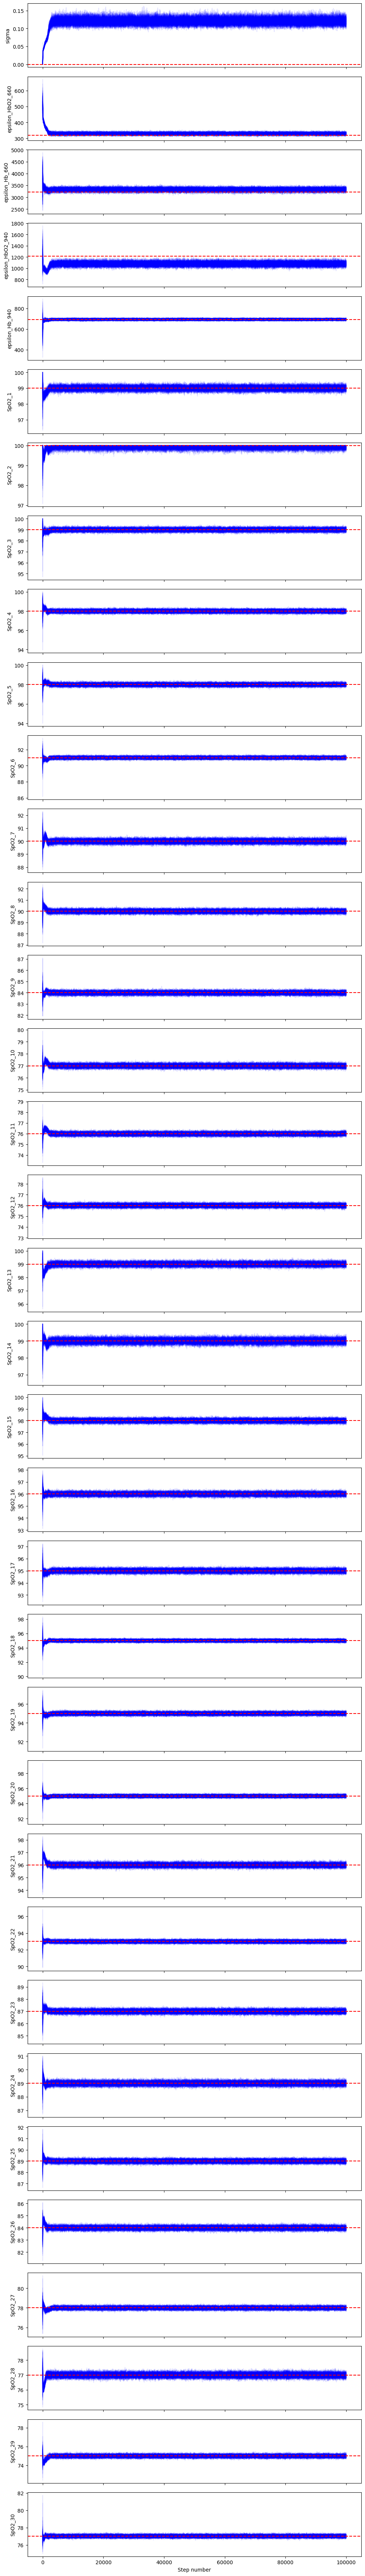

Temps d'autocorrélation pour chaque paramètre : [1644.39384858 1191.63891511  657.83563653 1081.19366754  734.72797138
  901.06648646  944.31782774  788.13496701  724.64559858  808.50707007
  808.54240844  647.94531094  798.80803394  683.38323614  745.32109653
  869.31944179  715.19916352 1019.30571027  754.51488429  915.57974226
  724.99729611  765.91313572  716.04122712  802.59549131  708.22779325
  906.09309197  738.46419084  759.9655964   635.78848962  731.61163473
  781.58014117  686.97414859  755.25190849  965.99713731  722.45433251]
Nombre d'échantillons indépendants : [ 60.81268188  83.9180382  152.01365576  92.49036782 136.1047951
 110.97960195 105.89654994 126.88182124 137.99849222 123.68475639
 123.67935059 154.33401294 125.18652261 146.3307771  134.17036022
 115.03251301 139.82119261  98.1059941  132.53549013 109.22041564
 137.9315489  130.56310871 139.65676306 124.59576597 141.1975087
 110.36393599 135.41618028 131.58490394 157.28501165 136.68454034
 127.94593252 145.56588

In [ ]:
param_names = ["sigma", "epsilon_HbO2_660", "epsilon_Hb_660", "epsilon_HbO2_940", "epsilon_Hb_940"] + [f"SpO2_{i+1}" for i in range(T)]
samples = sampler.get_chain(flat=True, thin=1000)

val_h = np.concatenate([[0, EPS_HBO2_660, EPS_HB_660, EPS_HBO2_940, EPS_HB_940], spo2_subsampled])
fig, axes = plt.subplots(n_dim, figsize=(10, 2 * n_dim), sharex=True)
for i, ax in enumerate(axes):
    for walker in range(n_walkers):
        ax.plot(sampler.chain[walker, :, i], color="blue", alpha=0.1)
    ax.axhline(y = val_h[i], color='r', linestyle='--')  
    ax.set_ylabel(param_names[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()


try:
    tau = sampler.get_autocorr_time()  
    print(f"Temps d'autocorrélation pour chaque paramètre : {tau}")
    print(f"Nombre d'échantillons indépendants : {n_steps / tau}")
except Exception as e:
    print(f"Erreur lors du calcul du temps d'autocorrélation : {e}")




Looking at the graphs above, we can see two axes of analysis in our approach. The first part is the parameters $\sigma$ and $\epsilon$. The second part is oxygen saturation. In general, we applied the log of convergence (`log_posterior`) which uses the ``log_likelihood`` and `log_prior` calculated previously. We have relatively low scales, which allows us to have a relatively small standard deviation around the convergence value. We performed 100,000 iterations, which is quite a large number but allows us to obtain a valid tau. We also added the values given in the assignment in red. 


For $\sigma$, we set the observed variable (red line) to zero, given that we have a value in the statement. As for the $\epsilon$ parameters, we can see that we have values slightly higher than the values given for $\epsilon_{660}$. For $\epsilon_{940}$, we have a lower value for $O_{2}$ and the other at the level given in the statement. 
For $SpO_{2}$, we observe that all values are around the value given in the statement. However, we apply a filter (clip) so that the values do not exceed 100%. 


Analysing my results, I find that the autocorrelation times $\tau$ vary from nearly 650 iterations for some $SpO_{2}$ indices to approximately 1,644 iterations for the $\sigma$ parameter, which means that each sample remains strongly correlated with its predecessors for several hundred steps. The absorption coefficients $\epsilon$ show intermediate values ($\approx$ 650–1,200), and the $SpO_{2}$ indices are generally between 646 and 1,020. Over a chain of 100,000 iterations, this ultimately provides only 60 to 150 truly independent samples per parameter, revealing moderate mixing.


<div class="alert alert-success">
    
**Exercise**. Plot the estimated posterior probability distribution of the parameters and discuss these results.
    
</div>

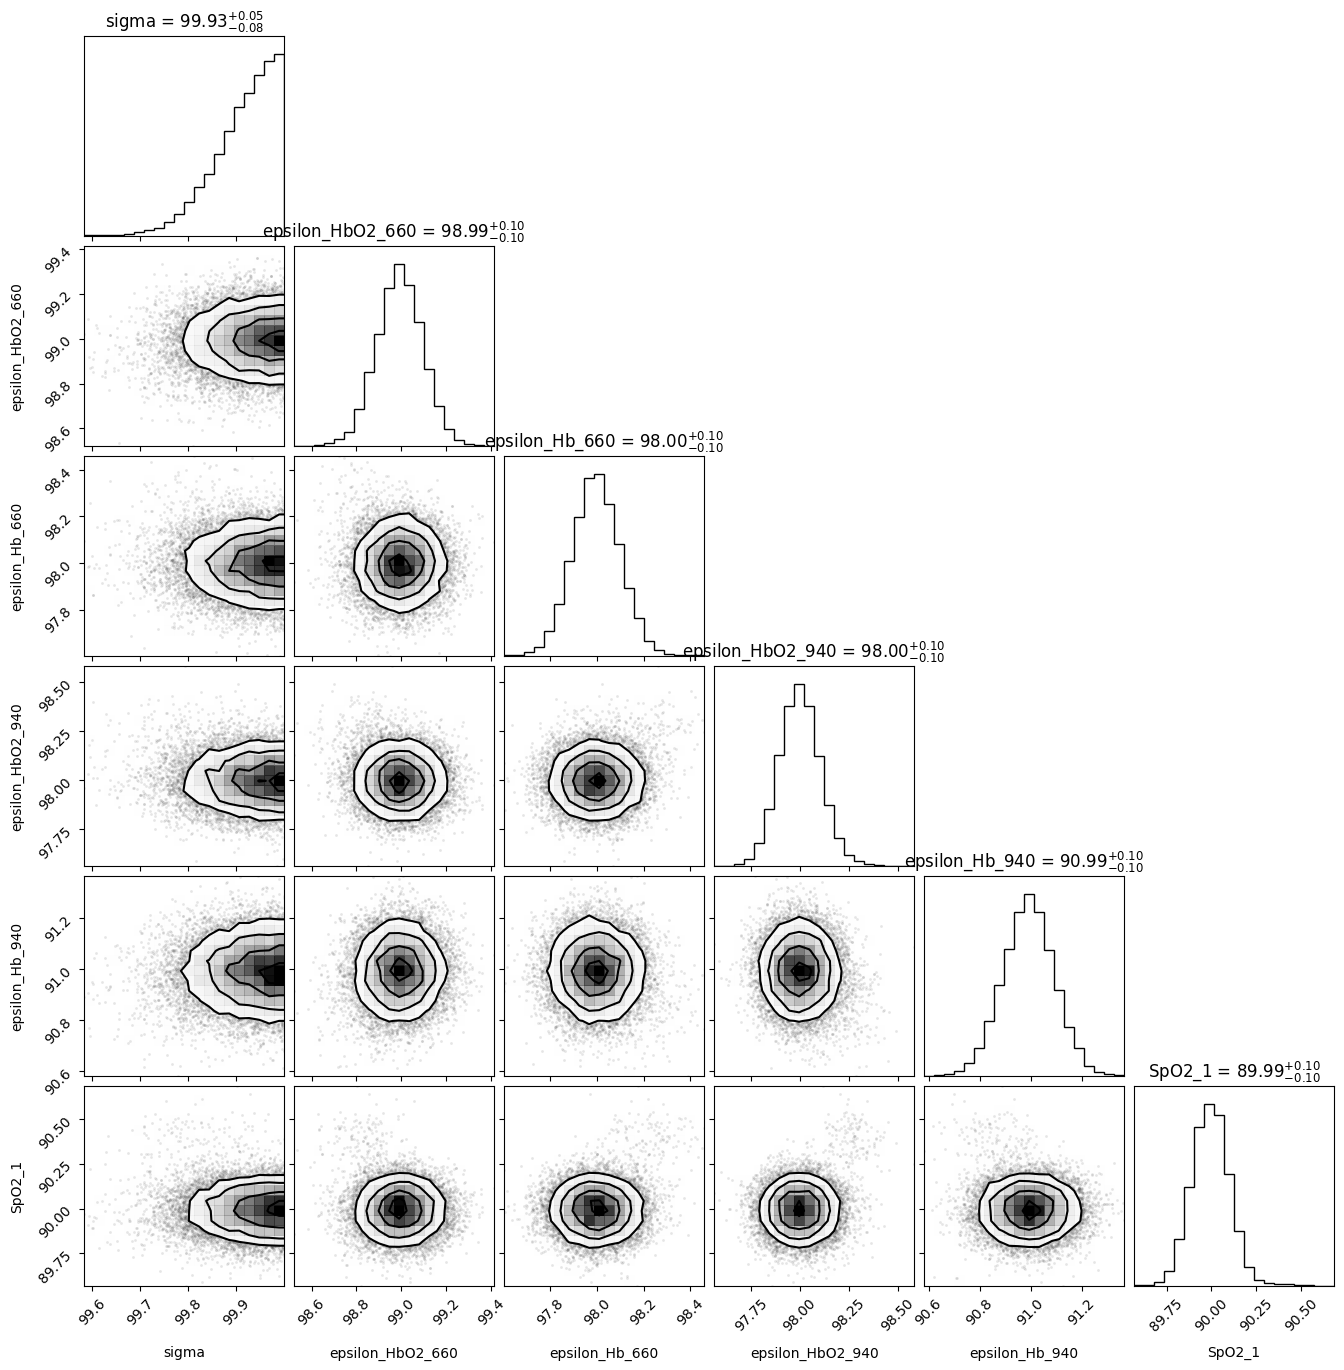

In [19]:


samples_spo2 = samples[:, 6:]  
spo2_labels = [f"SpO₂_{i+1}" for i in range(samples_spo2.shape[1])]  


fig = corner.corner(
    samples_spo2[:, :6],
    labels=param_names[:6],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)
plt.show()


The corner plot shows the distributions of each model parameter taken separately on the diagonal and the relationships between two parameters at a time outside the diagonal. The distributions on the diagonal are fairly tight and well centred, which means that the parameters are estimated with good accuracy and that the model is fairly confident in its values. The value of $\sigma$ is estimated at around 99.93 with very little variation, indicating that the level of noise or residual variability in the data is relatively constant. The four $\epsilon$ coefficients are also well defined with little uncertainty. We note that oxygen saturation ($SpO_{2}$) is estimated to be around 90% with low dispersion, which means that the model is confident in this estimate.

Looking at the graphs outside the diagonal, we see that most of the scatter plots are round, which shows that the parameters are not strongly correlated and that when one changes, the other does not change in a predictable way. The only notable exception is a slight positive correlation between $\epsilon_{HbO2}{660}$ and $\epsilon_{HbO2}{940}$ because when one increases, the other tends to increase as well. Overall, the graph shows that the parameters are estimated accurately and independently, which reinforces confidence in the reliability of the model's results.


## Part 3: Criticize

<div class="alert alert-success">
    
**Exercise**. Plot the estimated posterior probability distribution of the oximetry ($\text{SpO2}$).
First, display this posterior probability distribution throughout the subsampled time series of input oximetry $R_{1:T}$, and compare it to the observed oximetry $\text{SpO2}_{1:T}$. Then, ignore the temporal aspect and display the marginal posterior probability distribution of oximetry, along with the marginal observed distribution of oximetry ($\text{SpO2}$). Discuss the results.
    
</div>

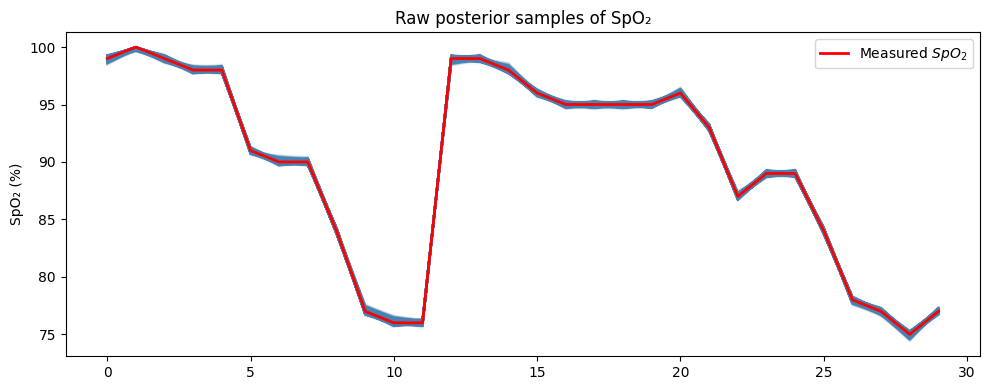

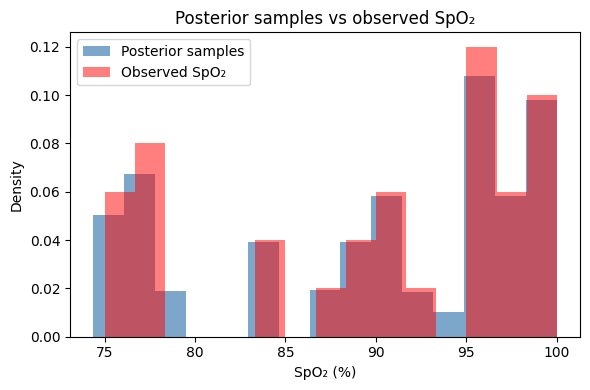

In [20]:
samples_spo2 = samples[:, 5: 5+T]
t = np.arange(T)


plt.figure(figsize=(10,4))
for row in samples_spo2:
    plt.plot(t, row, color="steelblue", alpha=0.02)

plt.plot(t, spo2_subsampled, color="red", lw=2, label="Measured $SpO_{2}$")

plt.ylabel("SpO₂ (%)")
plt.title("Raw posterior samples of SpO₂")
plt.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(6,4))
plt.hist(samples_spo2.ravel(), bins=15, alpha=0.7, density=True,
         color="steelblue", label="Posterior samples")
plt.hist(spo2_subsampled, bins=15, alpha=0.5, density=True,
         color="red", label="Observed SpO₂")

plt.xlabel("SpO₂ (%)")
plt.ylabel("Density")
plt.title("Posterior samples vs observed SpO₂")
plt.legend()
plt.tight_layout()
plt.show()


The raw posterior trajectories of $SpO_{2}$ (in blue) closely follow the measured time series (in red) throughout the period under consideration. The low dispersion of the trajectories indicates that the model is confident in its estimates, and the near-perfect overlap with the observations suggests that the model fits the data well. Ignoring the temporal aspect, the comparative histogram of the marginal distributions shows that the posterior distribution of $SpO_{2}$ largely overlaps with the observed distribution. The two distributions have similar modes and similar amplitudes, confirming that the model successfully reproduces not only the dynamics but also the overall distribution of the observed oxygen saturation values.



<div class="alert alert-success">
    
**Exercise**. Evaluate the posterior predictive distribution of $R_{1:T}$. Discuss the results.
        
</div>

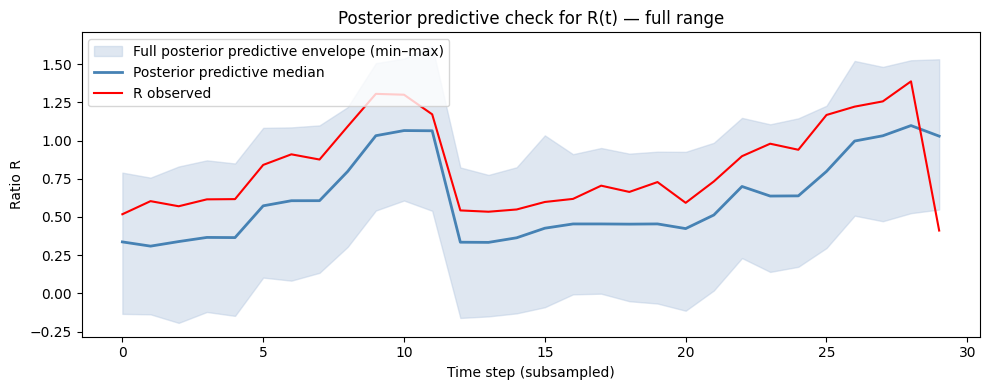

In [23]:

sigma      = samples[:, 0]
eps660o2   = samples[:, 1]
eps660Hb   = samples[:, 2]
eps940o2   = samples[:, 3]
eps940Hb   = samples[:, 4]
SpO2       = samples[:, 5 : 5+T]

S = SpO2 / 100.0
num   = S * eps660o2[:, None] + (1 - S) * eps660Hb[:, None]
denom = S * eps940o2[:, None] + (1 - S) * eps940Hb[:, None]
R_mean = num / denom
R_rep  = R_mean + np.random.randn(*R_mean.shape) * sigma[:, None]

R_lo = np.min(R_rep, axis=0)
R_hi = np.max(R_rep, axis=0)
R_med = np.median(R_rep, axis=0)


plt.figure(figsize=(10,4))
t = np.arange(T)

plt.fill_between(t, R_lo, R_hi, color="lightsteelblue", alpha=0.4,
                 label="Full posterior predictive envelope (min–max)")
plt.plot(t, R_med, color="steelblue", lw=2,
         label="Posterior predictive median")

plt.plot(t,R_subsampled,label="R observed", color="red")

plt.xlabel("Time step (subsampled)")
plt.ylabel("Ratio R")
plt.title("Posterior predictive check for R(t) — full range")
plt.legend()
plt.tight_layout()
plt.show()



The blue curve shows the median of the prediction of R(t) and the blue area represents the full range of values predicted by the model. The red curve corresponds to the measured values. We can see that the general shape of the red curve is closely followed by the blue curve, but that the predicted values are often lower than the observed values. We also note that some observed values exceed the blue area, especially when R(t) is high. This shows that the model does not always cover the full variability of the data.

<div class="alert alert-success">
    
**Exercise**. Evaluate the posterior predictive distributions of test quantities (statistics) of $R_{1:T}$. Discuss the results.
        
</div>

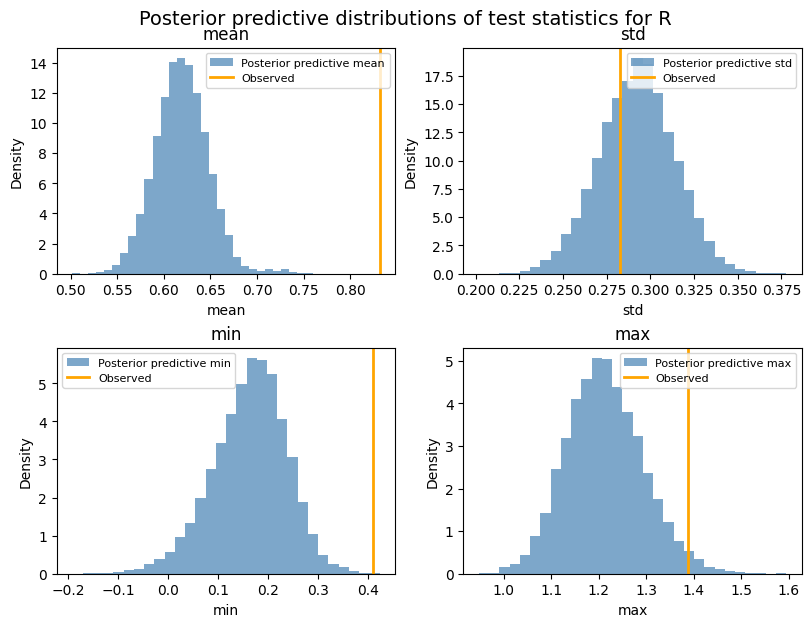

In [24]:
sigma      = samples[:, 0]
eps660o2   = samples[:, 1]
eps660Hb   = samples[:, 2]
eps940o2   = samples[:, 3]
eps940Hb   = samples[:, 4]
SpO2       = samples[:, 5 : 5+T]

S = SpO2 / 100.0
num   = S * eps660o2[:,None] + (1 - S) * eps660Hb[:,None]
denom = S * eps940o2[:,None] + (1 - S) * eps940Hb[:,None]
R_mean = num / denom
R_rep  = R_mean + np.random.randn(*R_mean.shape) * sigma[:,None]

R_obs = R_subsampled

stats = {
    "mean": R_rep.mean(axis=1), 
    "std" : R_rep.std(axis=1, ddof=0),
    "min" : R_rep.min(axis=1),
    "max" : R_rep.max(axis=1)
}
obs_stats = {
    "mean": R_obs.mean(),
    "std" : R_obs.std(ddof=0),
    "min" : R_obs.min(),
    "max" : R_obs.max()
}

n_stats = len(stats)
ncols   = 2
nrows   = int(np.ceil(n_stats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows),
                         constrained_layout=True)
axes = axes.flatten()

for i, (name, arr) in enumerate(stats.items()):
    ax = axes[i]
    ax.hist(arr, bins=30, color="steelblue", alpha=0.7, density=True,
            label=f"Posterior predictive {name}")
    ax.axvline(obs_stats[name], color="orange", lw=2, label="Observed")
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Posterior predictive distributions of test statistics for R", y=1.02, fontsize=14)
plt.show()


The graph shows the model's predicted distributions for the mean, standard deviation, minimum, and maximum of R(t), with the observed values indicated by the orange lines. For the standard deviation, the observed value is at the centre of the predicted distribution, which means that the model accurately reproduces the overall variability of R(t). However, for the mean, minimum and maximum, the observed values are higher than what the model predicts and sometimes even outside the most probable range. This shows that the model tends to underestimate the mean level and extreme values of R(t). These differences may be due to poorly modelled noise or simplifications that prevent the model from accurately representing all the variation present in the data.

<div class="alert alert-success">
    
**Exercise**. Evaluate the performance of the model quantitatively. Motivate your metric(s) and discuss.
        
</div>

In [25]:
squared_err = (R_med - R_subsampled)**2
abs_err     = np.abs(R_med - R_subsampled)

rmse = np.sqrt(squared_err.mean())
mae  = abs_err.mean()

print(f"RMSE : {rmse:0.4f}")
print(f"MAE : {mae:0.4f}")


RMSE : 0.2676
MAE : 0.2528


To evaluate the model's performance, we used two metrics. RMSE (Root Mean Squared Error) measures the average quadratic error between predicted and observed values. It is sensitive to large errors and allows us to evaluate the overall accuracy of the model. The MAE (Mean Absolute Error) measures the mean absolute error and gives a simple idea of the mean difference between the prediction and the observation, in units of R. The results obtained are an RMSE of 0.2676 and an MAE of 0.2528, which corresponds to a relatively small average deviation. This shows that the model generally reproduces the observations well, even if there is room for improvement, particularly in terms of better predicting certain extreme values.

<div class="alert alert-success">
    
**Exercise**. Criticize the model and propose an improvement. Implementing this improvement is not required.
        
</div>

The results show that the model tends to underestimate the mean value and extreme values of R(t). Some actual measurements are also outside the range predicted by the model, which means that it does not capture all the variability in the data. The noise is assumed to be constant and Gaussian, which is probably too simple for this type of data. 

To improve the model, we could use noise that varies over time or according to the signal level, or a Student's t-distribution or alpha distribution to better handle extreme values. We could also add a bias term to correct for the underestimation.

The autocorrelation time values are pretty high ($\approx$ 650–1,644), which means the MCMC chains are mixing slowly and the samples are pretty correlated. As a result, out of 100,000 iterations, only about 60 to 150 truly independent samples are obtained per parameter, which limits the accuracy of the estimates. This problem could be mitigated by adjusting the proposal distribution to reduce correlations, increasing the number of walkers or chains to better explore the parameter space, or reparameterising the model to reduce strong dependencies between parameters.